# Makemore Part 2: MLP Language Model

Karpathy の [makemore](https://github.com/karpathy/makemore) シリーズ第2回。
Bigram モデル（直前の1文字のみ参照）の限界を克服するため、**多層パーセプトロン（MLP）** を用いて直前の複数の文字（コンテキスト）から次の文字を予測します。

参考論文: [A Neural Probabilistic Language Model (Bengio et al., 2003)](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

## 学習内容
1. **コンテキストサイズ（block_size）の導入** — 前 $N$ 文字を見る
2. **埋め込み（Embedding）** — 文字を高次元ベクトル空間に配置
3. **隠れ層（Hidden Layer）** — 非線形変換（tanh）
4. **ミニバッチ学習とデータ分割** — Train / Val / Test 分割による過学習の評価

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.5.1+cpu


## 1. データの準備と語彙の構築

In [2]:
words = open('../data/names.txt', 'r').read().splitlines()
print(f"Total words: {len(words)}")

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f"Vocabulary size: {vocab_size}")

Total words: 32033
Vocabulary size: 27


## 2. データセットの構築 (コンテキストウィンドウ)

`block_size`（コンテキスト長）を設定し、直前の `block_size` 個の文字から次の1文字を予測するデータセットを作成します。

In [3]:
block_size = 3 # 前の3文字を見て次の文字を予測

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size # 初期コンテキストは '...' (0,0,0)
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # コンテキストを1つずらす
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)

# 80% Train, 10% Val, 10% Test 分割
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Training set: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Validation set: X={Xdev.shape}, Y={Ydev.shape}")
print(f"Test set: X={Xte.shape}, Y={Yte.shape}")

Training set: X=torch.Size([182625, 3]), Y=torch.Size([182625])
Validation set: X=torch.Size([22655, 3]), Y=torch.Size([22655])
Test set: X=torch.Size([22866, 3]), Y=torch.Size([22866])


## 3. モデルのパラメータ初期化

MLPモデルのアーキテクチャ：
1. **Embedding Layer**: 27文字 $\to$ $N$ 次元空間へマッピング
2. **Hidden Layer**: $N \times \text{block\_size}$ の入力を受け取り、tanh で活性化
3. **Output Layer**: 隠れ層から 27個のロジットを出力

In [4]:
g = torch.Generator().manual_seed(2147483647)

n_embd = 10 # 文字の埋め込み次元数
n_hidden = 200 # 隠れ層のニューロン数

C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
# 修正前
# W2 = torch.randn((n_hidden, vocab_size), generator=g)
# b2 = torch.randn(vocab_size, generator=g)

# 修正後: W2を非常に小さくし、b2はゼロにする
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0


parameters = [C, W1, b1, W2, b2]
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
    p.requires_grad = True

Total parameters: 11897


## 4. 学習ループ (ミニバッチ学習)

全データで一度に計算すると重すぎるため、**ミニバッチ**（小さなデータの束）をランダムに選んで学習します。

In [5]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # 1. ミニバッチの作成
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # 2. 順伝播 (Forward pass)
    emb = C[Xb] # (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1) # (32, 30)
    h = torch.tanh(embcat @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Yb)
    
    # 3. 逆伝播 (Backward pass)
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # 4. パラメータ更新 (Learning rate decay を含む)
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
        
    # 統計の記録
    lossi.append(loss.log10().item())
    
    if i % 10000 == 0:
        print(f"step {i:7d}/{max_steps:7d}: loss {loss.item():.4f}")

print("Training completed.")

step       0/ 200000: loss 3.3221
step   10000/ 200000: loss 2.1900
step   20000/ 200000: loss 2.4196
step   30000/ 200000: loss 2.6067
step   40000/ 200000: loss 2.0601
step   50000/ 200000: loss 2.4988
step   60000/ 200000: loss 2.3902
step   70000/ 200000: loss 2.1344
step   80000/ 200000: loss 2.3369
step   90000/ 200000: loss 2.1299
step  100000/ 200000: loss 1.8329
step  110000/ 200000: loss 2.2053
step  120000/ 200000: loss 1.8540
step  130000/ 200000: loss 2.4566
step  140000/ 200000: loss 2.1879
step  150000/ 200000: loss 2.1118
step  160000/ 200000: loss 1.8956
step  170000/ 200000: loss 1.8645
step  180000/ 200000: loss 2.0326
step  190000/ 200000: loss 1.8417
Training completed.


## 5. 損失のプロット

ミニバッチごとの損失はノイズが多いため、プロットする際に少し平滑化すると傾向が見やすくなります。

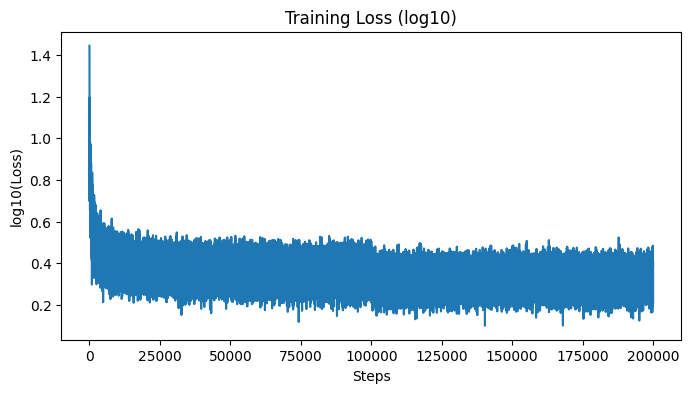

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(lossi)
plt.title('Training Loss (log10)')
plt.xlabel('Steps')
plt.ylabel('log10(Loss)')
plt.show()

## 6. モデルの評価 (Train & Val Loss)

訓練データだけでなく、検証データ（Validation set）での損失を測ることで、過学習（Overfitting）していないか確認します。

In [7]:
@torch.no_grad() # 評価時は勾配計算を無効化（メモリと速度の節約）
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.1249
val loss: 2.1698


Bigram モデルの NLL は約 `2.45` だったので、MLPにすることで性能が大きく向上していることがわかります！

## 7. 名前のサンプリング

学習済みのMLPモデルを使って、新しい名前を生成してみます。

In [8]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # '...' からスタート
    
    while True:
        # 順伝播
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # サンプリング
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        # コンテキストの更新
        context = context[1:] + [ix]
        out.append(ix)
        
        # 終端トークンが出たら終了
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out[:-1]))

mona
mayah
see
mel
rylle
emmasiendrael
adered
elin
shy
jen
edennestanaraylyn
malke
cayshuberlyni
jest
jair
jeniph
terofio
zen
dariyah
faeh


## 8. 埋め込み (Embedding) の可視化

文字が学習によって高次元空間（この場合は10次元ですが、もし2次元にしていたらプロット可能）でどのように配置されたかを可視化できます。似た役割を持つ文字（例えば母音同士）が近くに配置される傾向があります。